# 02 - Data Cleaning and Exploratory Data Analysis

## Credit Risk Modelling Using Logistic Regression

This notebook applies the project's cleaning rules, records each change, and examines borrower characteristics against serious delinquency. It does not fit a predictive model or engineer features.

## Objective and target

The target is `SeriousDlqin2yrs`, where 1 denotes serious delinquency within two years and 0 denotes no serious delinquency. We use the term **default rate** below as shorthand for the observed proportion with this target equal to 1; it is a descriptive sample rate, not a causal effect or an individual Probability of Default estimate.

The cleaning transformations are implemented in the reusable module `src/preprocessing.py` and called from this notebook. The raw data frame is retained for before-and-after comparisons. The cleaned data will be written to `data/processed/cleaned_data.csv` for the next project stage.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, "../src")
from preprocessing import clean_data
from evaluation import default_rate_by_bin

# Run this notebook from notebooks/ in the stated repository structure.
DATA_PATH = "../data/raw/cs-training.csv"
OUT_PATH = "../data/processed/cleaned_data.csv"
TARGET = "SeriousDlqin2yrs"
ID_COL = "Unnamed: 0"

raw_data = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH}")
print(f"Raw observations: {len(raw_data):,} | variables: {raw_data.shape[1]:,}")

Loaded ../data/raw/cs-training.csv
Raw observations: 150,000 | variables: 12


## 1. Raw target distribution

Notebook 01 documents the dataset profile, including variable roles, distinct values, and baseline missingness. This section keeps the raw target baseline; the before-and-after missingness comparison follows the cleaning step.


In [2]:
base_n = len(raw_data)
target_n = raw_data[TARGET].value_counts(dropna=False).sort_index()
target_profile = pd.DataFrame({"count": target_n, "share": target_n / base_n, "percent": target_n / base_n * 100})
display(target_profile.round({"share": 6, "percent": 3}))


,count,share,percent
SeriousDlqin2yrs,,,
0,139974,0.93316,93.316
1,10026,0.06684,6.684


## 2. Duplicate and data-quality audit

Check exact duplicate rows both with all supplied fields and after excluding `Unnamed: 0`. A unique row identifier can make otherwise identical borrower records appear distinct, so both counts matter. We also quantify the predefined `age = 0` condition and missingness in fields that have cleaning rules.

In [3]:
full_dup = int(raw_data.duplicated().sum())
no_id_dup = int(raw_data.drop(columns=[ID_COL]).duplicated().sum())
print(f"Exact duplicate rows with all fields: {full_dup:,}")
print(f"Exact duplicate rows excluding {ID_COL!r}: {no_id_dup:,}")
print(f"{ID_COL!r} is unique: {raw_data[ID_COL].is_unique}")
print(f"Age = 0 observations: {(raw_data['age'] == 0).sum():,}")


Exact duplicate rows with all fields: 0
Exact duplicate rows excluding 'Unnamed: 0': 609
'Unnamed: 0' is unique: True
Age = 0 observations: 1


## 3. Apply the predefined cleaning rules

The operations are applied in this order:

1. Remove the index-like `Unnamed: 0` column.
2. Remove duplicate borrower rows after excluding that identifier, keeping the first occurrence.
3. Remove observations with `age = 0`.
4. Replace missing `MonthlyIncome` with the mean of observed, **non-zero** income in the retained data. Observed zero incomes remain zero.
5. Remove observations with missing `NumberOfDependents`.

No other observations are removed. In particular, extreme values are retained for investigation.

In [4]:
cleaned_data, clean_log, income_info = clean_data(raw_data)
display(clean_log)
print(f"Imputation mean from {income_info['income_donor_count']:,} observed non-zero incomes: {income_info['income_mean']:,.2f}")
print(f"Observed zero incomes retained: {income_info['zero_income_retained']:,}")


,step,affected,unit,remaining_rows
0,Starting observations,0,rows,150000
1,Remove index identifier,1,column,150000
2,Remove duplicate rows,609,rows,149391
3,Remove age = 0 rows,1,rows,149390
4,Impute missing MonthlyIncome,29221,cells,149390
5,Remove missing dependents,3828,rows,145562


Imputation mean from 118,553 observed non-zero incomes: 6,766.09
Observed zero incomes retained: 1,616


## 4. Verify cleaning outcomes and compare missingness

These checks confirm the specified rules were applied while retaining the original target and all non-identifier borrower characteristics. Missingness is compared before and after cleaning; zeros in `MonthlyIncome` are counted separately from missing values.

In [5]:
raw_cols = [c for c in raw_data.columns if c != ID_COL]
miss_check = pd.DataFrame({
    "raw_missing": raw_data[raw_cols].isna().sum(),
    "cleaned_missing": cleaned_data.isna().sum().reindex(raw_cols),
})
display(miss_check)

print(f"Final shape: {cleaned_data.shape}")
print(f"Remaining exact duplicate rows: {cleaned_data.duplicated().sum():,}")
print(f"Remaining age = 0 rows: {(cleaned_data['age'] == 0).sum():,}")
print(f"Remaining missing MonthlyIncome: {cleaned_data['MonthlyIncome'].isna().sum():,}")
print(f"Remaining missing NumberOfDependents: {cleaned_data['NumberOfDependents'].isna().sum():,}")
print(f"Remaining zero MonthlyIncome: {cleaned_data['MonthlyIncome'].eq(0).sum():,}")

,raw_missing,cleaned_missing
SeriousDlqin2yrs,0,0
RevolvingUtilizationOfUnsecuredLines,0,0
age,0,0
NumberOfTime30-59DaysPastDueNotWorse,0,0
DebtRatio,0,0
MonthlyIncome,29731,0
NumberOfOpenCreditLinesAndLoans,0,0
NumberOfTimes90DaysLate,0,0
NumberRealEstateLoansOrLines,0,0
NumberOfTime60-89DaysPastDueNotWorse,0,0


Final shape: (145562, 11)
Remaining exact duplicate rows: 0
Remaining age = 0 rows: 0
Remaining missing MonthlyIncome: 0
Remaining missing NumberOfDependents: 0
Remaining zero MonthlyIncome: 1,616


## 5. Cleaned-data distributions and summary statistics

Quantiles and skewness help describe scale and asymmetry, especially for income, utilization, and the debt ratio. These summaries are descriptive; they do not trigger further transformations in this stage.

In [6]:
summary = cleaned_data.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
summary["skewness"] = cleaned_data.skew(numeric_only=True)
display(summary)

clean_n = len(cleaned_data)
clean_target = cleaned_data[TARGET].value_counts().sort_index()
clean_target = pd.DataFrame({"count": clean_target, "share": clean_target / clean_n, "percent": clean_target / clean_n * 100})
display(clean_target.round({"share": 6, "percent": 3}))

,count,mean,std,min,1%,25%,50%,75%,99%,max,skewness
SeriousDlqin2yrs,145562.0,0.067538,0.250953,0.0,0.0,0.000000,0.000000,0.000000,1.000000,1.0,3.446608
RevolvingUtilizationOfUnsecuredLines,145562.0,5.941412,250.511696,0.0,0.0,0.031217,0.158812,0.561072,1.093822,50708.0,98.976067
age,145562.0,52.111059,14.567062,21.0,24.0,41.000000,52.000000,62.000000,86.000000,107.0,0.192743
NumberOfTime30-59DaysPastDueNotWorse,145562.0,0.389181,3.756956,0.0,0.0,0.000000,0.000000,0.000000,4.000000,98.0,25.048977
DebtRatio,145562.0,334.550547,1947.234701,0.0,0.0,0.173933,0.359088,0.770648,4934.390000,329664.0,101.284484
MonthlyIncome,145562.0,6690.976661,13074.449284,0.0,0.0,3816.000000,6400.000000,7500.000000,23334.390000,3008750.0,125.480385
NumberOfOpenCreditLinesAndLoans,145562.0,8.553805,5.141145,0.0,0.0,5.000000,8.000000,11.000000,25.000000,58.0,1.221558
NumberOfTimes90DaysLate,145562.0,0.231310,3.728816,0.0,0.0,0.000000,0.000000,0.000000,3.000000,98.0,25.739687
NumberRealEstateLoansOrLines,145562.0,1.033340,1.133116,0.0,0.0,0.000000,1.000000,2.000000,5.000000,54.0,3.488460
NumberOfTime60-89DaysPastDueNotWorse,145562.0,0.205624,3.712468,0.0,0.0,0.000000,0.000000,0.000000,2.000000,98.0,26.086913


,count,share,percent
SeriousDlqin2yrs,,,
0,135731,0.932462,93.246
1,9831,0.067538,6.754


## 6. Correlation analysis

The Pearson correlations below are descriptive linear associations. They can miss non-linear risk relationships and should not be interpreted causally. The correlation with `SeriousDlqin2yrs` is included as an initial summary, not as a feature-selection rule.

In [7]:
corr = cleaned_data.corr(numeric_only=True)
target_corr = corr[TARGET].drop(TARGET).sort_values()
display(target_corr.rename("pearson_correlation_with_target").to_frame().round(3))
display(corr.round(2))

,pearson_correlation_with_target
age,-0.114
NumberOfOpenCreditLinesAndLoans,-0.032
MonthlyIncome,-0.018
NumberRealEstateLoansOrLines,-0.009
DebtRatio,-0.008
RevolvingUtilizationOfUnsecuredLines,-0.002
NumberOfDependents,0.046
NumberOfTime60-89DaysPastDueNotWorse,0.104
NumberOfTimes90DaysLate,0.121
NumberOfTime30-59DaysPastDueNotWorse,0.130


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
SeriousDlqin2yrs,1.00,-0.00,-0.11,0.13,-0.01,-0.02,-0.03,0.12,-0.01,0.10,0.05
RevolvingUtilizationOfUnsecuredLines,-0.00,1.00,-0.01,-0.00,0.00,0.01,-0.01,-0.00,0.01,-0.00,0.00
age,-0.11,-0.01,1.00,-0.05,0.03,0.03,0.16,-0.05,0.04,-0.05,-0.21
NumberOfTime30-59DaysPastDueNotWorse,0.13,-0.00,-0.05,1.00,-0.01,-0.01,-0.05,0.98,-0.03,0.98,0.00
DebtRatio,-0.01,0.00,0.03,-0.01,1.00,-0.00,0.05,-0.01,0.12,-0.01,-0.04
MonthlyIncome,-0.02,0.01,0.03,-0.01,-0.00,1.00,0.08,-0.01,0.11,-0.01,0.06
NumberOfOpenCreditLinesAndLoans,-0.03,-0.01,0.16,-0.05,0.05,0.08,1.00,-0.07,0.43,-0.06,0.06
NumberOfTimes90DaysLate,0.12,-0.00,-0.05,0.98,-0.01,-0.01,-0.07,1.00,-0.04,0.99,-0.01
NumberRealEstateLoansOrLines,-0.01,0.01,0.04,-0.03,0.12,0.11,0.43,-0.04,1.00,-0.04,0.12
NumberOfTime60-89DaysPastDueNotWorse,0.10,-0.00,-0.05,0.98,-0.01,-0.01,-0.06,0.99,-0.04,1.00,-0.01


## 7. Outlier and extreme-value review

The 1.5×IQR fences provide a conventional flag for unusually distant observations. Credit variables are often skewed and legitimate high-risk borrowers can lie beyond these fences, so the counts below are diagnostic only. No values or observations are removed by this analysis.

In [8]:
review_cols = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome",
    "NumberOfTime30-59DaysPastDueNotWorse", "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate", "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents",
]
out_rows = []
for col in review_cols:
    vals = cleaned_data[col].dropna()
    q1 = float(vals.quantile(0.25))
    q3 = float(vals.quantile(0.75))
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    out_n = int(((vals < low) | (vals > high)).sum())
    out_rows.append({"variable": col, "q1": q1, "median": float(vals.median()), "q3": q3,
                     "lower_fence": low, "upper_fence": high, "outside_iqr": out_n,
                     "outside_percent": 100 * out_n / len(vals)})
outlier_summary = pd.DataFrame(out_rows).set_index("variable")
display(outlier_summary.round(3))

,q1,median,q3,lower_fence,upper_fence,outside_iqr,outside_percent
variable,,,,,,,
RevolvingUtilizationOfUnsecuredLines,0.031,0.159,0.561,-0.764,1.356,736,0.506
age,41.000,52.000,62.000,9.500,93.500,117,0.080
DebtRatio,0.174,0.359,0.771,-0.721,1.666,28235,19.397
MonthlyIncome,3816.000,6400.000,7500.000,-1710.000,13026.000,8260,5.675
NumberOfTime30-59DaysPastDueNotWorse,0.000,0.000,0.000,0.000,0.000,23542,16.173
NumberOfOpenCreditLinesAndLoans,5.000,8.000,11.000,-4.000,20.000,3951,2.714
NumberOfTimes90DaysLate,0.000,0.000,0.000,0.000,0.000,8113,5.574
NumberRealEstateLoansOrLines,0.000,1.000,2.000,-3.000,5.000,787,0.541
NumberOfTime60-89DaysPastDueNotWorse,0.000,0.000,0.000,0.000,0.000,7435,5.108


## 8. Domain-oriented data-quality checks

Review negative numeric values and selected plausibility or scale flags after applying the predefined cleaning rules. These flags identify observations for interpretation; they are not additional removal criteria. Ratios above 1 and extreme delinquency counts may reflect source conventions or genuine records, so they are retained.

In [9]:
num_data = cleaned_data.select_dtypes(include="number")
neg_counts = (num_data < 0).sum()
neg_table = pd.DataFrame({"negative_count": neg_counts, "minimum": num_data.min()})
display(neg_table)

quality_flags = {
    "age > 100": cleaned_data["age"] > 100,
    "utilization > 1": cleaned_data["RevolvingUtilizationOfUnsecuredLines"] > 1,
    "DebtRatio > 1": cleaned_data["DebtRatio"] > 1,
    "30-59 day count > 20": cleaned_data["NumberOfTime30-59DaysPastDueNotWorse"] > 20,
    "60-89 day count > 20": cleaned_data["NumberOfTime60-89DaysPastDueNotWorse"] > 20,
    "90+ day count > 20": cleaned_data["NumberOfTimes90DaysLate"] > 20,
}
quality_table = pd.DataFrame({"flagged_count": {name: int(mask.sum()) for name, mask in quality_flags.items()}})
quality_table["flagged_percent"] = quality_table["flagged_count"] / len(cleaned_data) * 100
display(quality_table.round({"flagged_percent": 4}))

,negative_count,minimum
SeriousDlqin2yrs,0,0.0
RevolvingUtilizationOfUnsecuredLines,0,0.0
age,0,21.0
NumberOfTime30-59DaysPastDueNotWorse,0,0.0
DebtRatio,0,0.0
MonthlyIncome,0,0.0
NumberOfOpenCreditLinesAndLoans,0,0.0
NumberOfTimes90DaysLate,0,0.0
NumberRealEstateLoansOrLines,0,0.0
NumberOfTime60-89DaysPastDueNotWorse,0,0.0


,flagged_count,flagged_percent
age > 100,10,0.0069
utilization > 1,3260,2.2396
DebtRatio > 1,31686,21.7680
30-59 day count > 20,208,0.1429
60-89 day count > 20,208,0.1429
90+ day count > 20,208,0.1429


## 9. Default rates across borrower characteristics

For each interval, calculate borrower and event counts and the observed default rate. The bins show broad patterns and tail behavior; interpret rates from small groups cautiously. These rates describe associations in this dataset.


In [10]:
risk_bins = {
    "age": [0, 25, 35, 45, 55, 65, 75, np.inf],
    "MonthlyIncome": [0, 1, 2000, 4000, 6000, 10000, 15000, 25000, np.inf],
    "DebtRatio": [0, 0.1, 0.25, 0.5, 1, 2, 5, 25, 100, np.inf],
    "RevolvingUtilizationOfUnsecuredLines": [0, 0.1, 0.3, 0.5, 0.75, 1, 2, 5, np.inf],
    "NumberOfTime30-59DaysPastDueNotWorse": [0, 1, 2, 3, 5, 10, 21, np.inf],
    "NumberOfTime60-89DaysPastDueNotWorse": [0, 1, 2, 3, 5, 10, 21, np.inf],
    "NumberOfTimes90DaysLate": [0, 1, 2, 3, 5, 10, 21, np.inf],
    "NumberOfDependents": [0, 1, 2, 3, 4, 5, np.inf],
    "NumberOfOpenCreditLinesAndLoans": [0, 1, 3, 6, 10, 15, 20, np.inf],
}
for feature, bins in risk_bins.items():
    print(f"Observed default rate by {feature}")
    display(default_rate_by_bin(cleaned_data, feature, bins, target=TARGET))

Observed default rate by age


,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 25.0)",1769,195,11.023
1,"[25.0, 35.0)",16750,1890,11.284
2,"[35.0, 45.0)",28238,2561,9.069
3,"[45.0, 55.0)",36135,2806,7.765
4,"[55.0, 65.0)",33301,1618,4.859
5,"[65.0, 75.0)",19010,543,2.856
6,"[75.0, inf)",10359,218,2.104


Observed default rate by MonthlyIncome


,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 1.0)",1616,65,4.022
1,"[1.0, 2000.0)",9178,847,9.229
2,"[2000.0, 4000.0)",27399,2549,9.303
3,"[4000.0, 6000.0)",28848,2140,7.418
4,"[6000.0, 10000.0)",58736,3374,5.744
5,"[10000.0, 15000.0)",14076,591,4.199
6,"[15000.0, 25000.0)",4399,197,4.478
7,"[25000.0, inf)",1310,68,5.191


Observed default rate by DebtRatio


...

,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 1.0)",137449,6441,4.686
1,"[1.0, 2.0)",5130,1734,33.801
2,"[2.0, 3.0)",1522,760,49.934
3,"[3.0, 5.0)",945,571,60.423
4,"[5.0, 10.0)",284,187,65.845
5,"[10.0, 21.0)",24,13,54.167
6,"[21.0, inf)",208,125,60.096


Observed default rate by NumberOfDependents


,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 1.0)",86392,5079,5.879
1,"[1.0, 2.0)",26314,1935,7.354
2,"[2.0, 3.0)",19520,1584,8.115
3,"[3.0, 4.0)",9483,837,8.826
4,"[4.0, 5.0)",2862,297,10.377
5,"[5.0, inf)",991,99,9.990


Observed default rate by NumberOfOpenCreditLinesAndLoans


,bin,borrowers,defaults,default_rate_percent
0,"[0.0, 1.0)",1587,448,28.229
1,"[1.0, 3.0)",10105,1146,11.341
2,"[3.0, 6.0)",32141,2206,6.864
3,"[6.0, 10.0)",49666,2732,5.501
4,"[10.0, 15.0)",34746,2073,5.966
5,"[15.0, 20.0)",12204,855,7.006
6,"[20.0, inf)",5113,371,7.256


## 10. Distribution plots

The figures show selected distributions in the cleaned data alongside the summary statistics and default-rate tables.

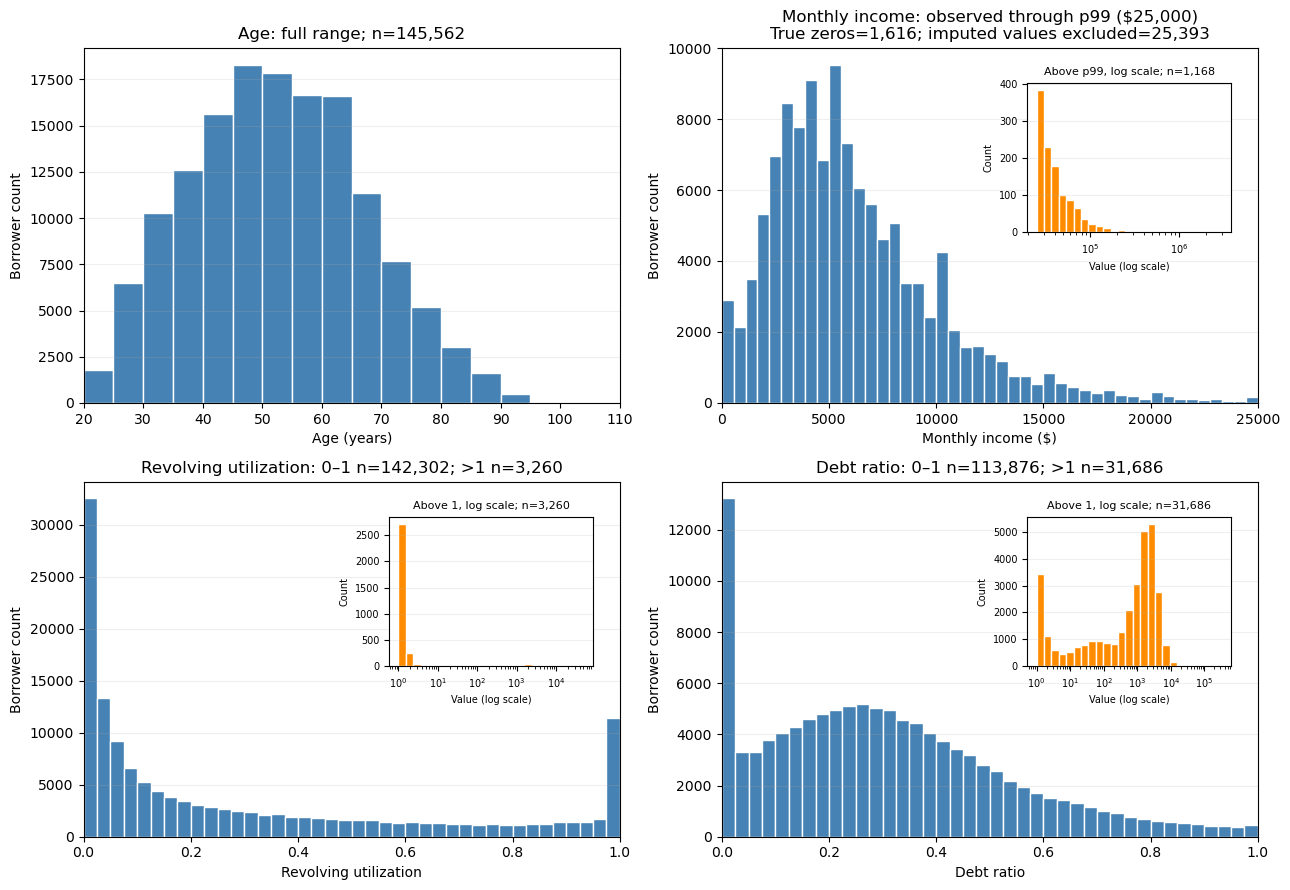

In [11]:
# Keep imputed incomes out of this distribution view so the mean-fill does not
# create a false spike. The raw row index is retained by clean_data for matching.
income_raw = raw_data.loc[cleaned_data.index, "MonthlyIncome"]
income_observed = income_raw.dropna()
income_imputed = int(income_raw.isna().sum())
income_q99 = float(income_observed.quantile(0.99))
income_core = income_observed.loc[income_observed <= income_q99]
income_tail = income_observed.loc[income_observed > income_q99]

util_col = "RevolvingUtilizationOfUnsecuredLines"
util_core = cleaned_data.loc[cleaned_data[util_col].le(1), util_col]
util_tail = cleaned_data.loc[cleaned_data[util_col].gt(1), util_col]

debt_col = "DebtRatio"
debt_core = cleaned_data.loc[cleaned_data[debt_col].le(1), debt_col]
debt_tail = cleaned_data.loc[cleaned_data[debt_col].gt(1), debt_col]


def draw_tail(ax, values, title):
    tail_ax = ax.inset_axes([0.57, 0.48, 0.38, 0.42])
    edges = np.geomspace(float(values.min()), float(values.max()), 26)
    tail_ax.hist(values, bins=edges, color="darkorange", edgecolor="white")
    tail_ax.set_xscale("log")
    tail_ax.set_title(f"{title}; n={len(values):,}", fontsize=8)
    tail_ax.set_xlabel("Value (log scale)", fontsize=7)
    tail_ax.set_ylabel("Count", fontsize=7)
    tail_ax.tick_params(axis="both", labelsize=7)
    tail_ax.grid(axis="y", alpha=0.2)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

age_vals = cleaned_data["age"]
axes[0, 0].hist(age_vals, bins=np.arange(20, 116, 5), color="steelblue", edgecolor="white")
axes[0, 0].set_xlim(20, 110)
axes[0, 0].set_title(f"Age: full range; n={len(age_vals):,}")
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].set_ylabel("Borrower count")

axes[0, 1].hist(income_core, bins=45, range=(0, income_q99), color="steelblue", edgecolor="white")
axes[0, 1].set_xlim(0, income_q99)
axes[0, 1].set_title(
    f"Monthly income: observed through p99 (${income_q99:,.0f})\n"
    f"True zeros={int(income_observed.eq(0).sum()):,}; imputed values excluded={income_imputed:,}"
)
axes[0, 1].set_xlabel("Monthly income ($)")
axes[0, 1].set_ylabel("Borrower count")
draw_tail(axes[0, 1], income_tail, "Above p99, log scale")

axes[1, 0].hist(util_core, bins=40, range=(0, 1), color="steelblue", edgecolor="white")
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_title(f"Revolving utilization: 0–1 n={len(util_core):,}; >1 n={len(util_tail):,}")
axes[1, 0].set_xlabel("Revolving utilization")
axes[1, 0].set_ylabel("Borrower count")
draw_tail(axes[1, 0], util_tail, "Above 1, log scale")

axes[1, 1].hist(debt_core, bins=40, range=(0, 1), color="steelblue", edgecolor="white")
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_title(f"Debt ratio: 0–1 n={len(debt_core):,}; >1 n={len(debt_tail):,}")
axes[1, 1].set_xlabel("Debt ratio")
axes[1, 1].set_ylabel("Borrower count")
draw_tail(axes[1, 1], debt_tail, "Above 1, log scale")

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()


## Distribution findings

The earlier full-range histograms used extreme maxima in the main x-axis, compressing the ordinary values near zero. These revised charts focus on the interpretable range and show excluded tails in log-scaled insets. The underlying cleaned data are unchanged.

- **Monthly income:** Among retained rows with originally observed income, **120,169** values are observed: **1,616** are genuine zeros and the median is **$5,400**. The 99th percentile is **$25,000**; the maximum is **$3,008,750**. The chart shows observed values through the 99th percentile and plots the tail separately. It excludes **25,393** mean-imputed incomes so imputation does not create an artificial peak at the mean.
- **Revolving utilization:** **142,302 of 145,562 (97.76%)** are between 0 and 1; the median is **0.159**. There are **3,260** values above 1 (2.24%), with a maximum of **50,708**. The main panel shows 0–1 and an inset shows values above 1 on a log scale.
- **Debt ratio:** **113,876 (78.23%)** are between 0 and 1, with a median of **0.359**. The other **31,686 (21.77%)** exceed 1; the maximum is **329,664**, so the raw column is not bounded by 1. Values above 1 are concentrated among records whose original income was missing (**96.3%** of that group) or zero (**94.1%**), compared with **4.8%** among records with positive observed income. This is a descriptive data pattern; the cleaning step imputes income but does not redefine or cap `DebtRatio`.

These views retain the tails as evidence and make their scale visible without letting them obscure the main distribution. They do not treat all values above 1 as errors.


## 11. Save the cleaned dataset

Save the Stage 2 result for downstream analysis. The raw CSV remains unchanged. The output has no index identifier, duplicate rows, age-zero rows, or missing dependents. Observed zero monthly incomes remain zero.


In [12]:
cleaned_data.to_csv(OUT_PATH, index=False)
print(f"Saved {len(cleaned_data):,} cleaned observations to {OUT_PATH}")

Saved 145,562 cleaned observations to ../data/processed/cleaned_data.csv


## Stage 2 summary

- Cleaning removed the index field, **609** duplicate rows, **1** age-zero row, and **3,828** rows with missing dependents. It imputed **29,221** missing income cells using the observed non-zero mean (**6,766.09**) and retained zero incomes.
- The saved dataset has **145,562 rows and 11 columns**, no missing values, no duplicate rows, and **9,831** serious-delinquency outcomes (**6.754%**).
- Prior delinquency and high revolving utilization show the clearest increases in observed default rates across bins. Age-group rates generally decline; income and debt-ratio patterns are less regular. Detailed distribution ranges, tail counts, and the debt-ratio/income relationship are reported above.
- Extreme values were reviewed and retained. No feature engineering or modelling was done; the cleaned dataset is ready for Stage 3 risk analysis and feature engineering.
